# Dating Profile EDA — Deep Exploratory Analysis
## Univariate · Correlations · Multivariate · Non-linear · Interaction Effects

Questions investigated:
1. Which traits matter most independently?
2. Which traits only help when attractiveness is high?
3. Which features compensate for low attractiveness?
4. Which combinations are strongest?
5. Are funny bios better only for certain profile types?
6. Does warmth outperform status after controlling for attractiveness?
7. Surprising findings & confounds

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import pointbiserialr, spearmanr, chi2_contingency, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False})

# ── Load clean data ─────────────────────────────────────────────────────────
df = pd.read_parquet("../data/df_clean.parquet")
y  = df["right_swipe?"].astype(int)

# Colour palette — consistent across all plots
C_LEFT  = "#d9534f"   # left swipe
C_RIGHT = "#5cb85c"   # right swipe
C_NEU   = "#6baed6"   # neutral
PALETTE = {0: C_LEFT, 1: C_RIGHT}

print(f"Loaded: {df.shape}   Right-swipe rate: {y.mean():.1%}")
df.head(2)

Loaded: (123, 49)   Right-swipe rate: 23.6%


,id,right_swipe?,n_photos,n_prompts,prompt_length,profession,bio_length,height,gym,smokes,...,warmth_vs_coldness,confidence_signaling,authenticity_score,intra_profile_consistency,first_photo_impact_score,humility_vs_braggadocio,attachment_style_proxy,emotional_stability,interesting_profile,profile_aura
0,1,0,4.0,1.0,2.0,1.0,3.0,191.0,active,no,...,2.0,2.0,NaN,1.0,1.0,1.0,secure,1.0,0.0,0.0
1,2,0,1.0,1.0,0.0,0.0,0.0,176.0,sometimes,sometimes,...,1.0,NaN,0.0,0.0,0.0,0.0,None,NaN,0.0,0.0


---
## 1. Univariate Association — Every Feature vs Right Swipe

Point-biserial correlation for numeric features, Cramér's V for nominal.  
All p-values are Benjamini-Hochberg corrected for multiple testing.

In [2]:
NUMERIC_FEATURES = [
    "height", "n_photos", "n_prompts", "prompt_length", "bio_length",
    "p_selfies", "p_smiling_photos", "p_half_body_photos", "eye_contact_ratio",
    "shirtless", "muscles", "pets", "friends_in_pics", "wears_specs", "filter",
    "has_music", "profession", "religious",
    "photo_lighting", "photo_quality", "perceived_conventional_attractiveness",
    "background_type_variance", "photo_curation_effort",
    "bio_tone", "bio_depth", "prompt_effort_depth",
    "perceived_social_status", "perceived_comfort", "perceived_humor",
    "perceived_genuineness", "perceived_wholesomeness", "warmth_vs_coldness",
    "confidence_signaling", "authenticity_score", "intra_profile_consistency",
    "first_photo_impact_score", "humility_vs_braggadocio",
    "emotional_stability", "interesting_profile", "profile_aura",
]

rows = []
for col in NUMERIC_FEATURES:
    valid = df[[col]].join(y).dropna()
    if len(valid) < 20 or valid[col].nunique() < 2:
        continue
    r, p = pointbiserialr(valid["right_swipe?"], valid[col])
    r_s, p_s = spearmanr(valid[col], valid["right_swipe?"])
    n0 = valid[valid["right_swipe?"] == 0][col].values
    n1 = valid[valid["right_swipe?"] == 1][col].values
    u_stat, p_mw = mannwhitneyu(n1, n0, alternative="two-sided")
    rows.append({"feature": col, "r_pearson": r, "p_pearson": p,
                 "r_spearman": r_s, "p_mw": p_mw,
                 "mean_left":  n0.mean(), "mean_right": n1.mean(),
                 "n": len(valid)})

assoc = pd.DataFrame(rows)
# BH correction on Mann-Whitney p-values
_, assoc["p_mw_bh"], _, _ = multipletests(assoc["p_mw"], method="fdr_bh")
assoc["sig"] = assoc["p_mw_bh"] < 0.05
assoc = assoc.sort_values("r_spearman", ascending=False)
print(assoc[["feature","r_spearman","p_mw_bh","sig","mean_left","mean_right"]].to_string(index=False))

                              feature  r_spearman      p_mw_bh   sig  mean_left  mean_right
                  emotional_stability    0.831442 3.140046e-14  True   0.181818    1.689655
              perceived_wholesomeness    0.734089 3.152612e-14  True   0.311111    1.724138
                   authenticity_score    0.718324 1.077270e-13  True   0.303371    1.689655
                perceived_genuineness    0.703379 2.854782e-13  True   0.382022    1.827586
                   warmth_vs_coldness    0.687286 5.723280e-13  True   0.422222    1.827586
                  interesting_profile    0.687171 5.723280e-13  True   0.233333    1.275862
                    perceived_comfort    0.684016 8.061947e-13  True   0.337079    1.586207
                         profile_aura    0.670729 1.644642e-12  True   0.122222    1.034483
                 confidence_signaling    0.667726 2.917597e-12  True   0.431818    1.724138
                      perceived_humor    0.586685 7.593124e-10  True   0.222222 

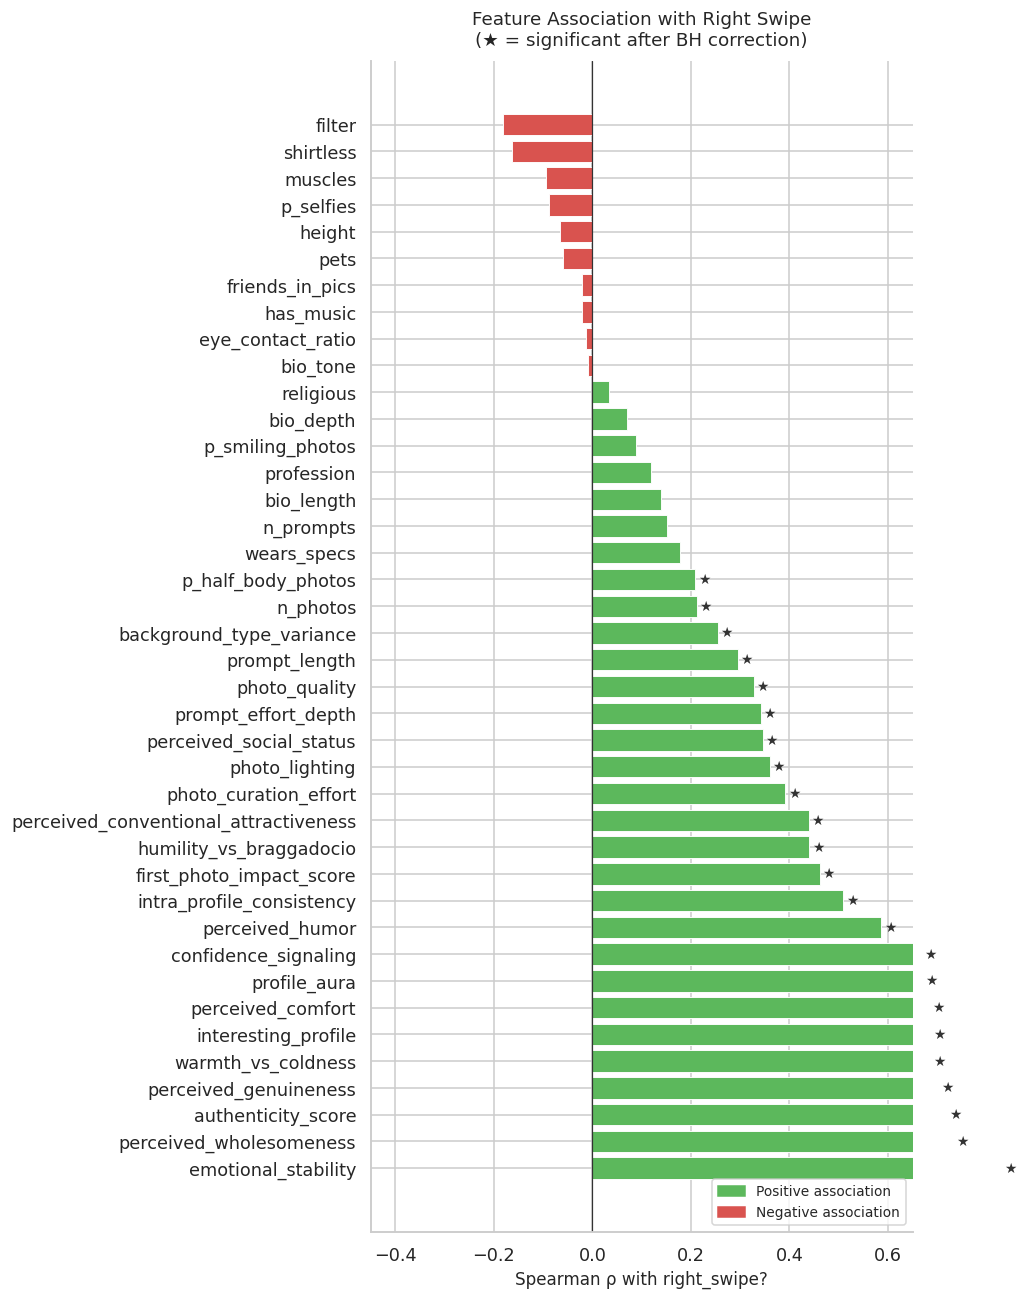

In [3]:
# ── Figure 1: Univariate association ranked chart ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 12))

colors = [C_RIGHT if v > 0 else C_LEFT for v in assoc["r_spearman"]]
bars = ax.barh(assoc["feature"], assoc["r_spearman"], color=colors, edgecolor="white", linewidth=0.6)

# Mark significant ones with a star
for i, (_, row) in enumerate(assoc.iterrows()):
    if row["sig"]:
        ax.text(row["r_spearman"] + (0.005 if row["r_spearman"] >= 0 else -0.005),
                i, "★", va="center", ha="left" if row["r_spearman"] >= 0 else "right",
                fontsize=9, color="#333")

ax.axvline(0, color="#333", linewidth=0.8)
ax.set_xlabel("Spearman ρ with right_swipe?", fontsize=11)
ax.set_title("Feature Association with Right Swipe\n(★ = significant after BH correction)", fontsize=12, pad=10)
ax.set_xlim(-0.45, 0.65)

patch_r = mpatches.Patch(color=C_RIGHT, label="Positive association")
patch_l = mpatches.Patch(color=C_LEFT,  label="Negative association")
ax.legend(handles=[patch_r, patch_l], loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("fig_eda_01_univariate_assoc.png", bbox_inches="tight")
plt.show()

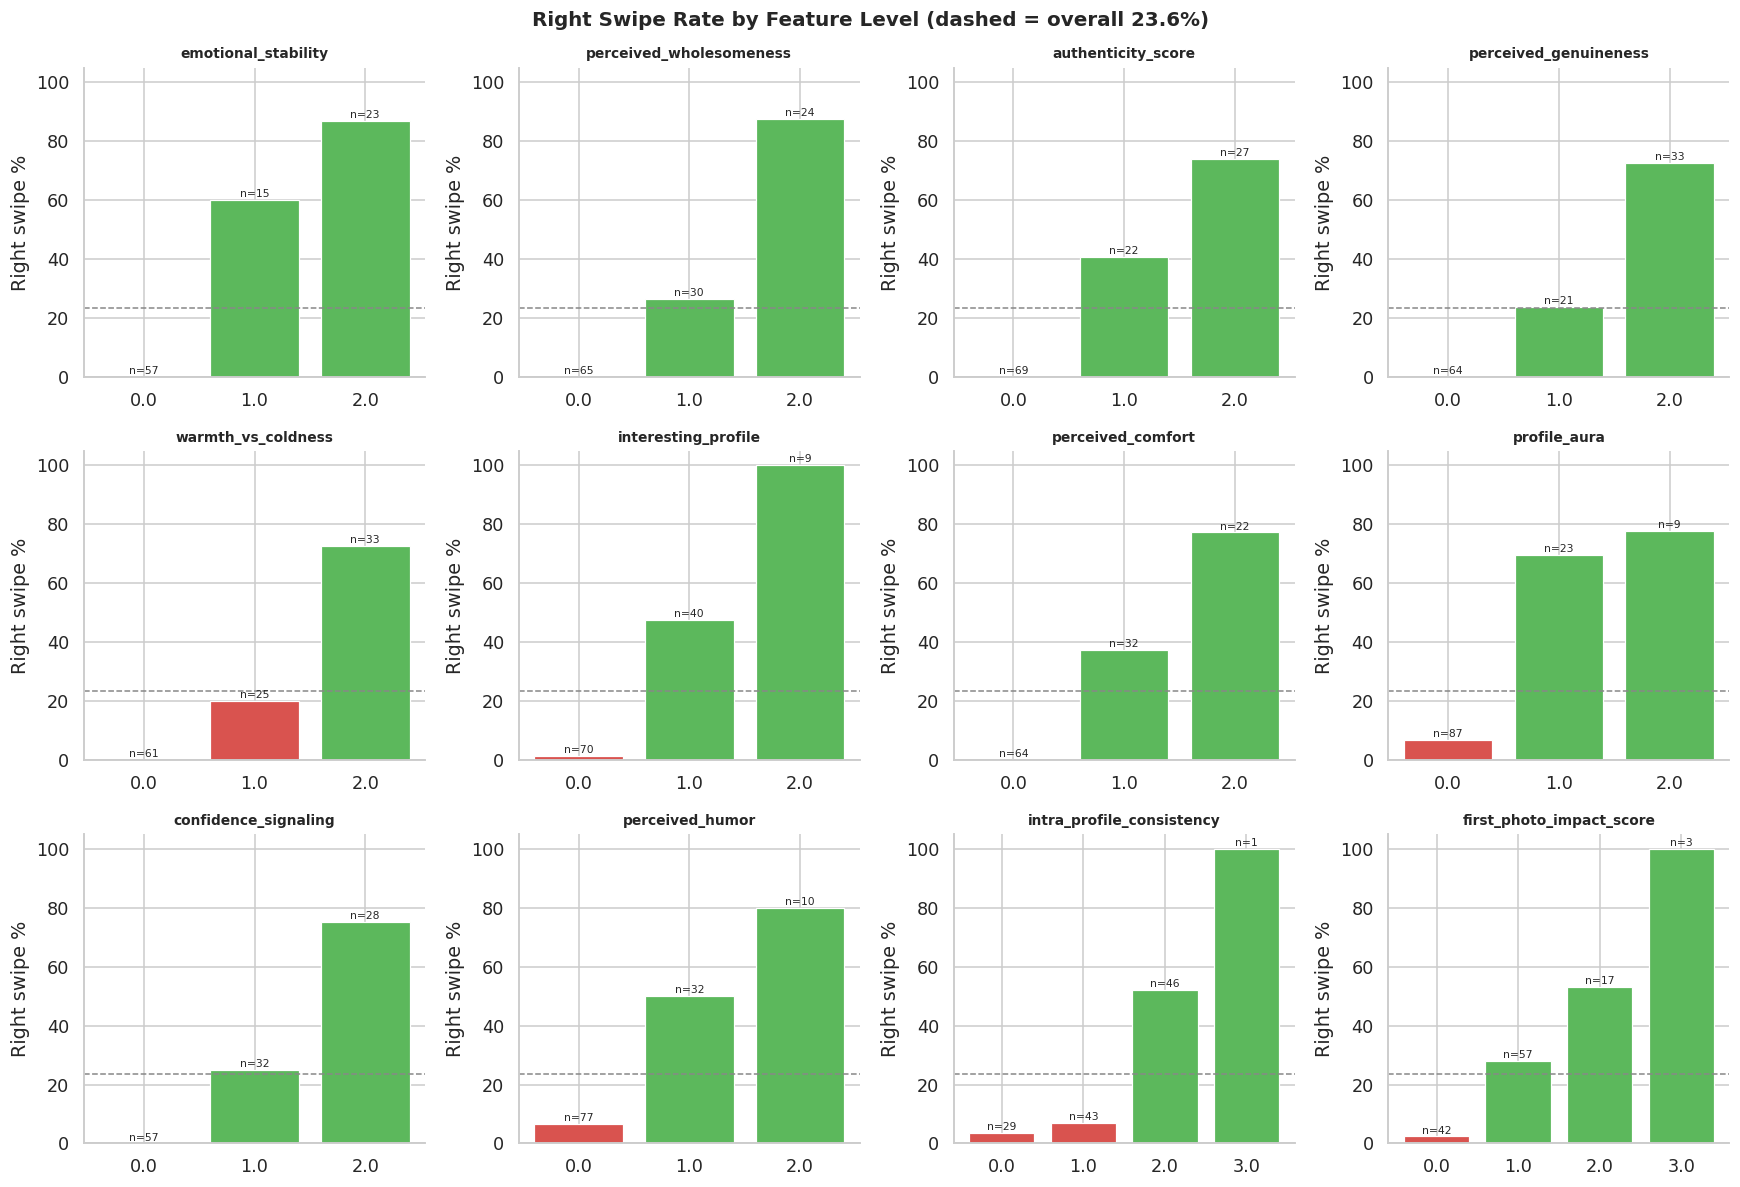

In [4]:
# ── Figure 2: Swipe rate per ordinal level for top significant features ───────
TOP_SIG = assoc[assoc["sig"]].sort_values("r_spearman", ascending=False)["feature"].tolist()[:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()

for i, col in enumerate(TOP_SIG):
    ax = axes[i]
    grp = df[[col, "right_swipe?"]].dropna()
    rates = grp.groupby(col)["right_swipe?"].agg(["mean", "count"]).reset_index()
    rates.columns = [col, "rate", "n"]
    bar_colors = [C_RIGHT if r > y.mean() else C_LEFT for r in rates["rate"]]
    ax.bar(rates[col].astype(str), rates["rate"] * 100,
           color=bar_colors, edgecolor="white", linewidth=0.8)
    ax.axhline(y.mean() * 100, color="#888", linestyle="--", linewidth=1, label="overall")
    for _, r in rates.iterrows():
        ax.text(str(r[col]), r["rate"] * 100 + 1, f"n={int(r['n'])}", ha="center", fontsize=7)
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.set_ylabel("Right swipe %")
    ax.set_ylim(0, 105)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Right Swipe Rate by Feature Level (dashed = overall 23.6%)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_eda_02_swiperate_by_level.png", bbox_inches="tight")
plt.show()

---
## 2. Correlation Structure & Multicollinearity

Among all numeric features: detect clusters of redundant variables (multicollinearity) and understand the inter-annotator conceptual overlaps.

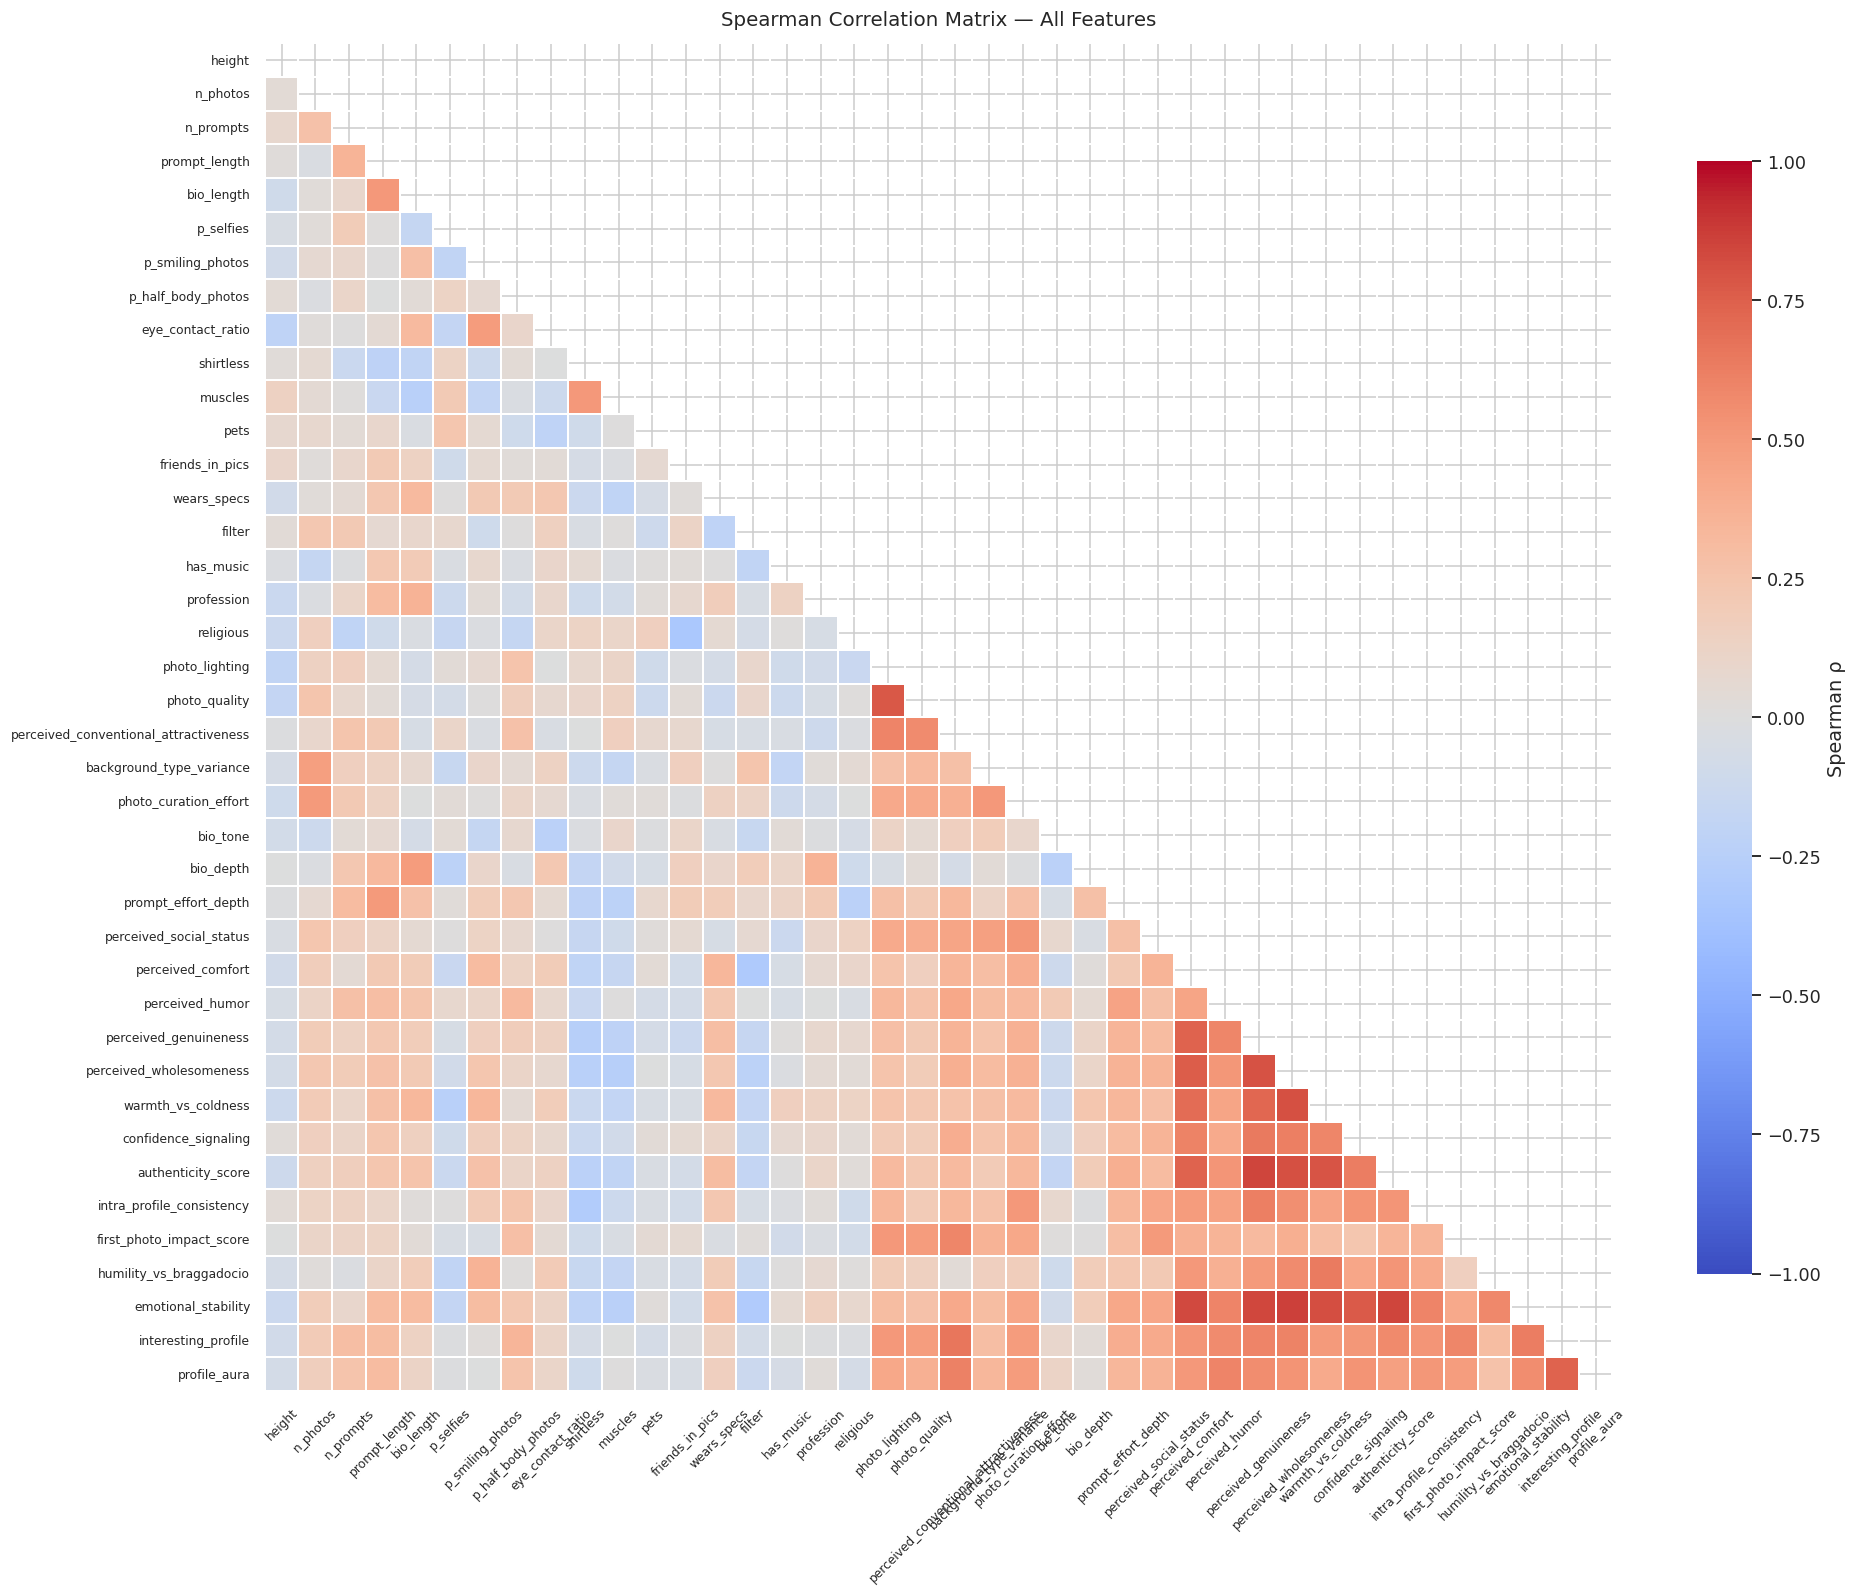

In [5]:
# ── Figure 3: Full Spearman correlation heatmap ──────────────────────────────
corr_cols = [c for c in NUMERIC_FEATURES if c in df.columns and df[c].nunique() > 1]
corr_df = df[corr_cols].copy()
spearman_corr = corr_df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(18, 16))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(spearman_corr, mask=mask, ax=ax,
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.3, square=True, annot=False,
            cbar_kws={"shrink": 0.7, "label": "Spearman ρ"})
ax.set_title("Spearman Correlation Matrix — All Features", fontsize=13, pad=12)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig("fig_eda_03_corr_heatmap.png", bbox_inches="tight")
plt.show()

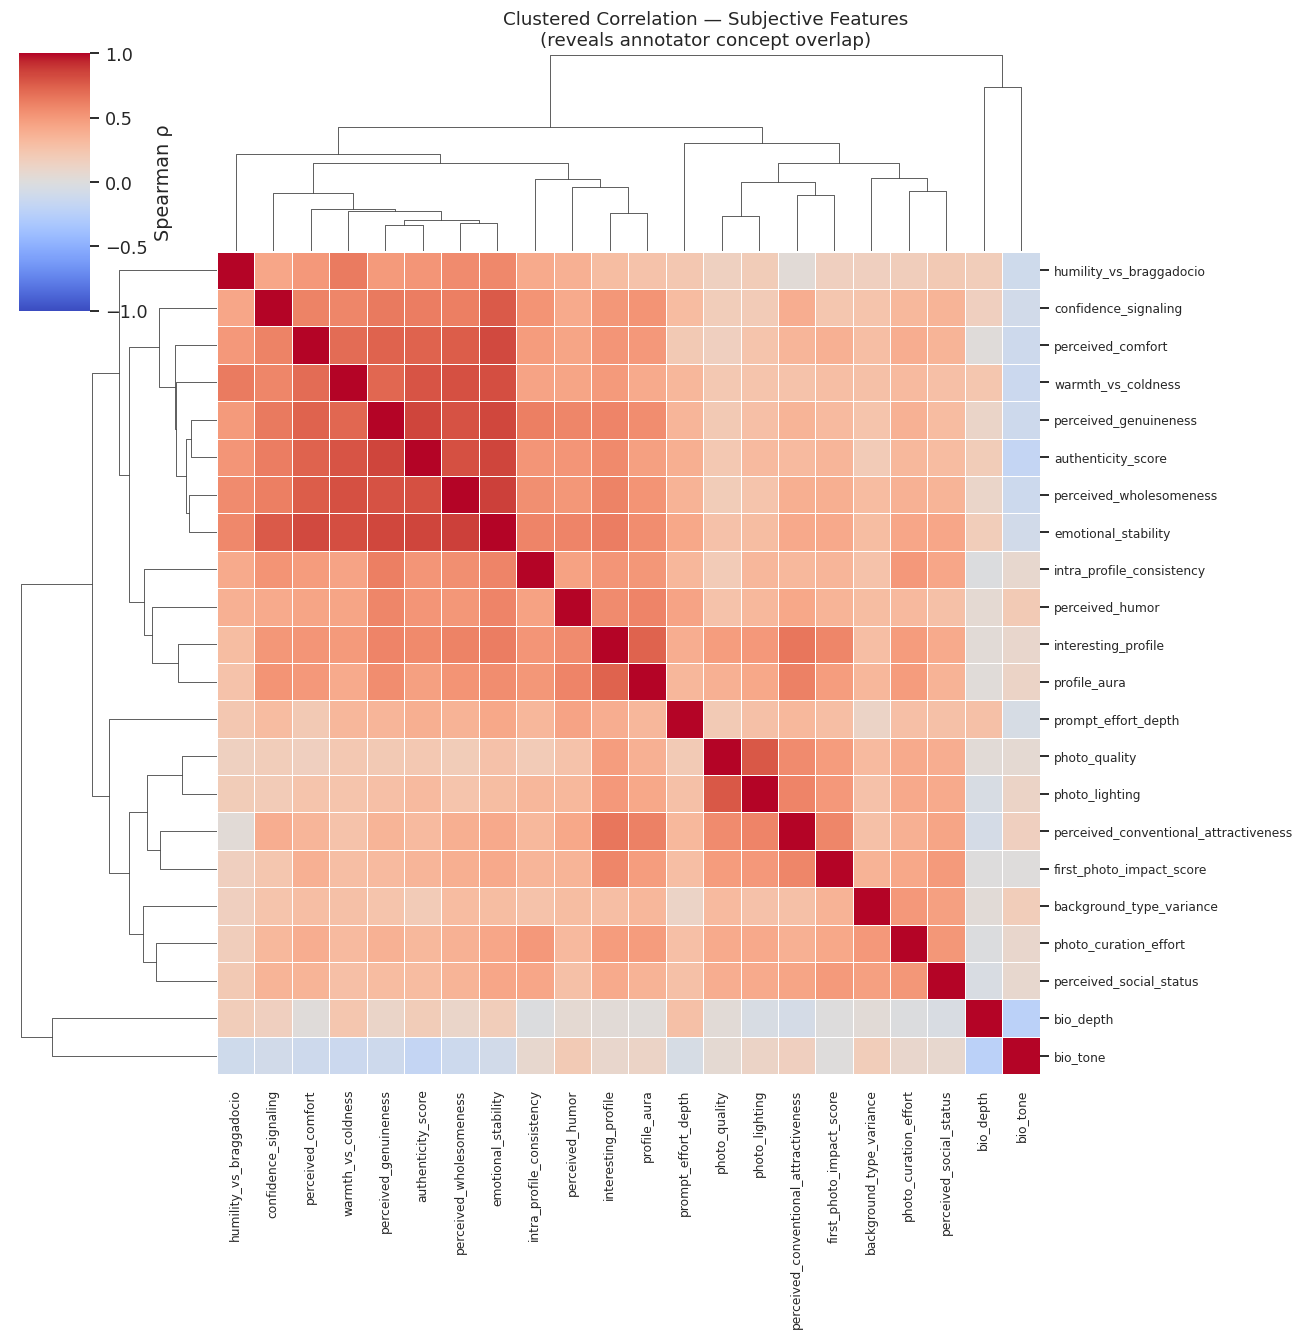

In [6]:
# ── Figure 4: Clustered heatmap — subjective features only ────────────────────
# Clustering reveals which annotator-rated concepts are really the same thing.
SUBJ = [
    "perceived_conventional_attractiveness", "photo_quality", "photo_lighting",
    "photo_curation_effort", "first_photo_impact_score", "background_type_variance",
    "perceived_social_status", "perceived_comfort", "perceived_humor",
    "perceived_genuineness", "perceived_wholesomeness", "warmth_vs_coldness",
    "confidence_signaling", "authenticity_score", "intra_profile_consistency",
    "humility_vs_braggadocio", "emotional_stability", "interesting_profile",
    "profile_aura", "bio_depth", "prompt_effort_depth", "bio_tone",
]
subj_valid = [c for c in SUBJ if c in df.columns]
subj_corr = df[subj_valid].corr(method="spearman")

g = sns.clustermap(subj_corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
                   linewidths=0.4, figsize=(13, 13),
                   cbar_kws={"label": "Spearman ρ"},
                   xticklabels=True, yticklabels=True)
g.ax_heatmap.tick_params(labelsize=8)
g.figure.suptitle("Clustered Correlation — Subjective Features\n(reveals annotator concept overlap)",
                   fontsize=12, y=1.01)
plt.savefig("fig_eda_04_subj_clustermap.png", bbox_inches="tight")
plt.show()

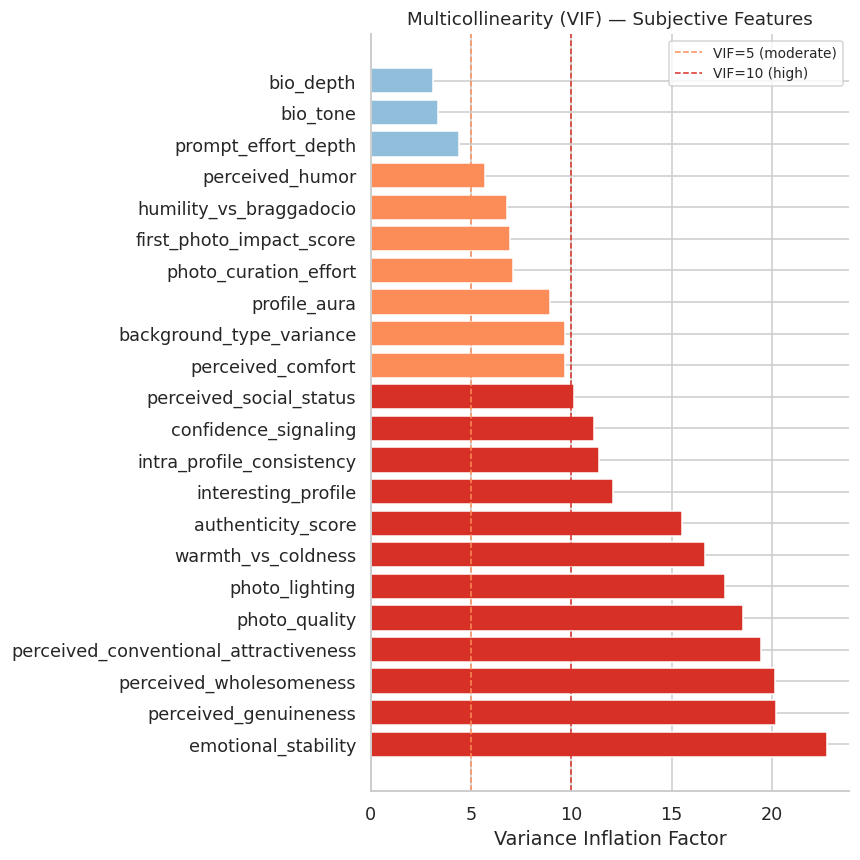


High-VIF features (>5) — consider dimensionality reduction or careful modelling:
emotional_stability                      22.730201
perceived_genuineness                    20.195971
perceived_wholesomeness                  20.141885
perceived_conventional_attractiveness    19.448762
photo_quality                            18.558238
photo_lighting                           17.682246
warmth_vs_coldness                       16.678920
authenticity_score                       15.541915
interesting_profile                      12.068578
intra_profile_consistency                11.370082
confidence_signaling                     11.111222
perceived_social_status                  10.143213
perceived_comfort                         9.694016
background_type_variance                  9.661117
profile_aura                              8.952648
photo_curation_effort                     7.108882
first_photo_impact_score                  6.939527
humility_vs_braggadocio                   6.778101


In [7]:
# ── VIF — detect multicollinearity quantitatively ───────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_cols = [c for c in subj_valid if c in df.columns]
vif_data = df[vif_cols].dropna()
vif_vals = pd.Series(
    [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])],
    index=vif_cols
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
colors_vif = ["#d73027" if v > 10 else "#fc8d59" if v > 5 else "#91bfdb" for v in vif_vals]
ax.barh(vif_vals.index, vif_vals.values, color=colors_vif, edgecolor="white")
ax.axvline(5,  color="#fc8d59", linestyle="--", linewidth=1, label="VIF=5 (moderate)")
ax.axvline(10, color="#d73027", linestyle="--", linewidth=1, label="VIF=10 (high)")
ax.set_xlabel("Variance Inflation Factor")
ax.set_title("Multicollinearity (VIF) — Subjective Features", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig_eda_05_vif.png", bbox_inches="tight")
plt.show()
print("\nHigh-VIF features (>5) — consider dimensionality reduction or careful modelling:")
print(vif_vals[vif_vals > 5].to_string())

---
## 3. Attractiveness Interaction — "Which traits only help when attractiveness is high?"

Split profiles into attractiveness tiers (low/med/high) and compare how strongly other features predict swipe within each tier.

Swipe rate by attractiveness tier:
                mean  count
attr_tier                  
Low (0-1)   0.037037     54
Mid (2)     0.368421     38
High (3-4)  0.481481     27


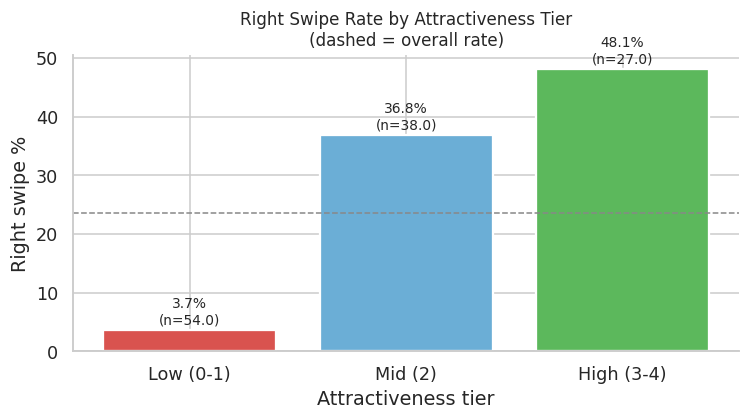

In [8]:
# ── Attractiveness tiers ─────────────────────────────────────────────────────
attr_col = "perceived_conventional_attractiveness"
dfA = df[[attr_col, "right_swipe?"]].dropna()

# Use quantile-based tiers to balance group sizes
dfA["attr_tier"] = pd.qcut(dfA[attr_col], q=3, labels=["Low (0-1)", "Mid (2)", "High (3-4)"])
tier_counts = dfA.groupby("attr_tier", observed=True)["right_swipe?"].agg(["mean", "count"])
print("Swipe rate by attractiveness tier:")
print(tier_counts)

fig, ax = plt.subplots(figsize=(7, 4))
tier_rates = tier_counts["mean"] * 100
colors_t = [C_LEFT, C_NEU, C_RIGHT]
bars = ax.bar(tier_rates.index.astype(str), tier_rates.values, color=colors_t,
              edgecolor="white", linewidth=1.5)
for bar, (_, row) in zip(bars, tier_counts.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{row['mean']*100:.1f}%\n(n={row['count']})",
            ha="center", fontsize=9)
ax.axhline(y.mean() * 100, color="#888", linestyle="--", linewidth=1)
ax.set_ylabel("Right swipe %")
ax.set_xlabel("Attractiveness tier")
ax.set_title("Right Swipe Rate by Attractiveness Tier\n(dashed = overall rate)", fontsize=11)
plt.tight_layout()
plt.savefig("fig_eda_06_attr_tiers.png", bbox_inches="tight")
plt.show()

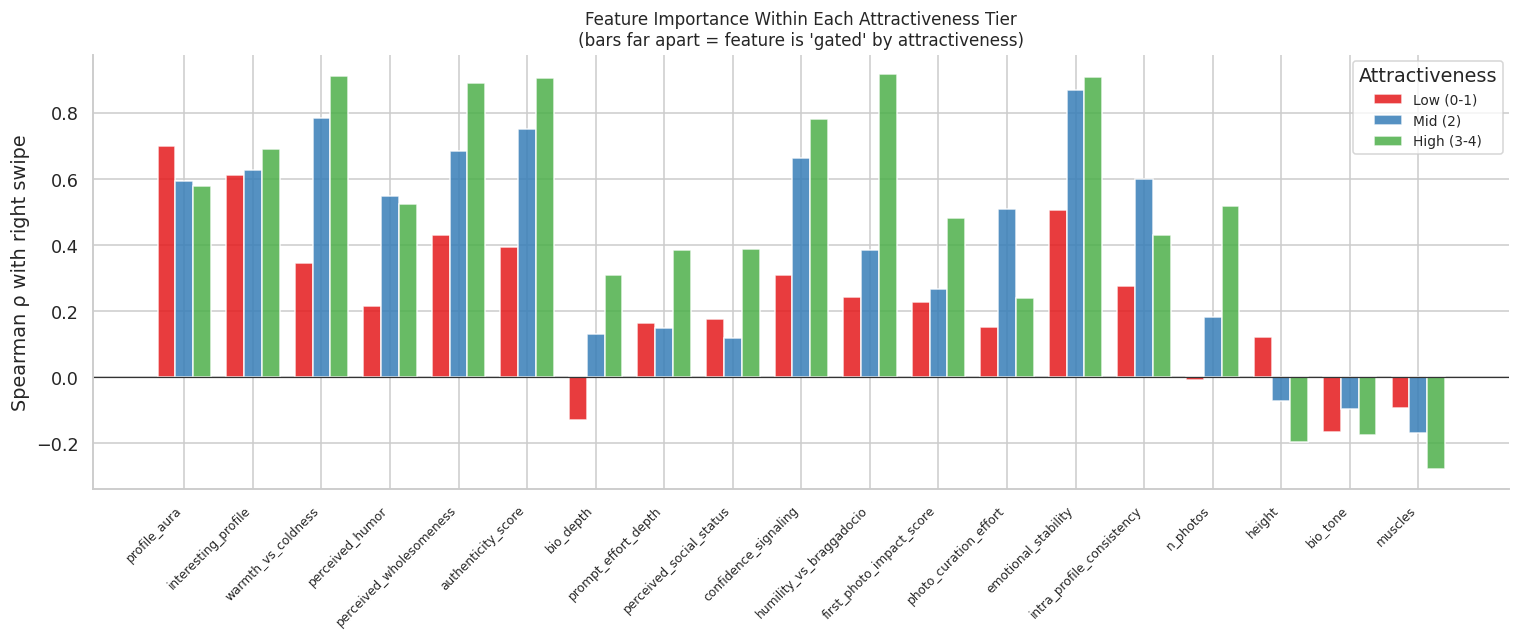

In [9]:
# ── Figure 6: Feature correlations within each attractiveness tier ────────────
# Features with very different ρ across tiers are "gated" by attractiveness.
tier_labels = ["Low (0-1)", "Mid (2)", "High (3-4)"]
tier_col = "attr_tier"
df_tiered = df.join(dfA[["attr_tier"]])

CANDIDATE_FEATURES = [
    "profile_aura", "interesting_profile", "warmth_vs_coldness", "perceived_humor",
    "perceived_wholesomeness", "authenticity_score", "bio_depth",
    "prompt_effort_depth", "perceived_social_status", "confidence_signaling",
    "humility_vs_braggadocio", "first_photo_impact_score", "photo_curation_effort",
    "emotional_stability", "intra_profile_consistency", "n_photos",
    "height", "bio_tone", "muscles",
]

tier_corr = {}
for tier in tier_labels:
    subset = df_tiered[df_tiered[tier_col] == tier]
    row = {}
    for col in CANDIDATE_FEATURES:
        valid = subset[[col, "right_swipe?"]].dropna()
        if len(valid) < 8:
            row[col] = np.nan
        else:
            r, _ = spearmanr(valid[col], valid["right_swipe?"])
            row[col] = r
    tier_corr[tier] = row

tier_df = pd.DataFrame(tier_corr).T

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(CANDIDATE_FEATURES))
width = 0.26
colors_t3 = ["#e41a1c", "#377eb8", "#4daf4a"]
for i, tier in enumerate(tier_labels):
    vals = [tier_df.loc[tier, c] if c in tier_df.columns else 0 for c in CANDIDATE_FEATURES]
    ax.bar(x + i * width, vals, width, label=tier, color=colors_t3[i],
           edgecolor="white", alpha=0.85)

ax.axhline(0, color="#333", linewidth=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(CANDIDATE_FEATURES, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Spearman ρ with right swipe")
ax.set_title("Feature Importance Within Each Attractiveness Tier\n(bars far apart = feature is 'gated' by attractiveness)", fontsize=11)
ax.legend(title="Attractiveness", fontsize=9)
plt.tight_layout()
plt.savefig("fig_eda_07_tier_interactions.png", bbox_inches="tight")
plt.show()

---
## 4. Compensation Features — "What helps low-attractiveness profiles?"

For profiles in the bottom attractiveness tier: which features are *more* predictive of a right swipe there than in the overall population?

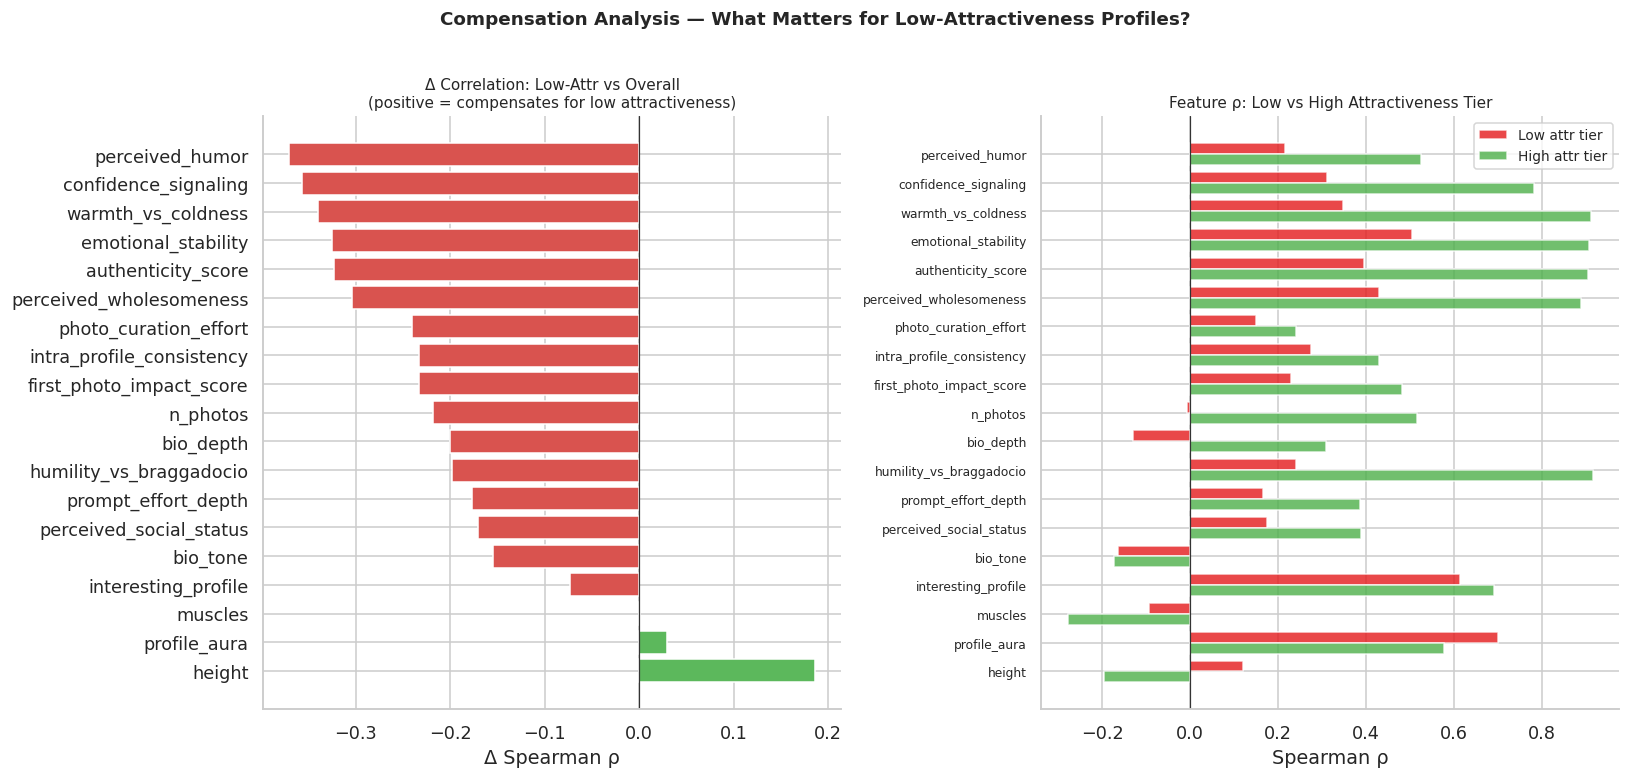

In [10]:
# ── Figure 8: Compensation features  ─────────────────────────────────────────
overall_corr = {}
for col in CANDIDATE_FEATURES:
    valid = df[[col, "right_swipe?"]].dropna()
    if len(valid) < 15:
        overall_corr[col] = np.nan
        continue
    r, _ = spearmanr(valid[col], valid["right_swipe?"])
    overall_corr[col] = r

low_corr = tier_df.loc["Low (0-1)"]
high_corr = tier_df.loc["High (3-4)"]
delta = low_corr - pd.Series(overall_corr)   # positive = more helpful for low-attractiveness

comp_df = pd.DataFrame({
    "overall_ρ": pd.Series(overall_corr),
    "low_attr_ρ": low_corr,
    "high_attr_ρ": high_corr,
    "delta_low_minus_overall": delta,
}).dropna(subset=["low_attr_ρ"])
comp_df = comp_df.sort_values("delta_low_minus_overall", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Left: delta
c_delta = [C_RIGHT if v > 0 else C_LEFT for v in comp_df["delta_low_minus_overall"]]
axes[0].barh(comp_df.index, comp_df["delta_low_minus_overall"], color=c_delta, edgecolor="white")
axes[0].axvline(0, color="#333", linewidth=0.8)
axes[0].set_title("Δ Correlation: Low-Attr vs Overall\n(positive = compensates for low attractiveness)", fontsize=10)
axes[0].set_xlabel("Δ Spearman ρ")

# Right: side-by-side bars for low vs high
x2 = np.arange(len(comp_df))
w = 0.38
axes[1].barh(x2 + w/2, comp_df["low_attr_ρ"], w, color="#e41a1c", alpha=0.8, label="Low attr tier")
axes[1].barh(x2 - w/2, comp_df["high_attr_ρ"], w, color="#4daf4a", alpha=0.8, label="High attr tier")
axes[1].set_yticks(x2)
axes[1].set_yticklabels(comp_df.index, fontsize=8)
axes[1].axvline(0, color="#333", linewidth=0.8)
axes[1].set_title("Feature ρ: Low vs High Attractiveness Tier", fontsize=10)
axes[1].set_xlabel("Spearman ρ")
axes[1].legend(fontsize=9)

plt.suptitle("Compensation Analysis — What Matters for Low-Attractiveness Profiles?",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig_eda_08_compensation.png", bbox_inches="tight")
plt.show()

---
## 5. Bio Tone Interaction — "Are funny bios better for certain profile types?"

Investigate whether `bio_tone=1` (funny) vs `bio_tone=0` (serious) has different effects depending on attractiveness tier, warmth score, and confidence signaling.

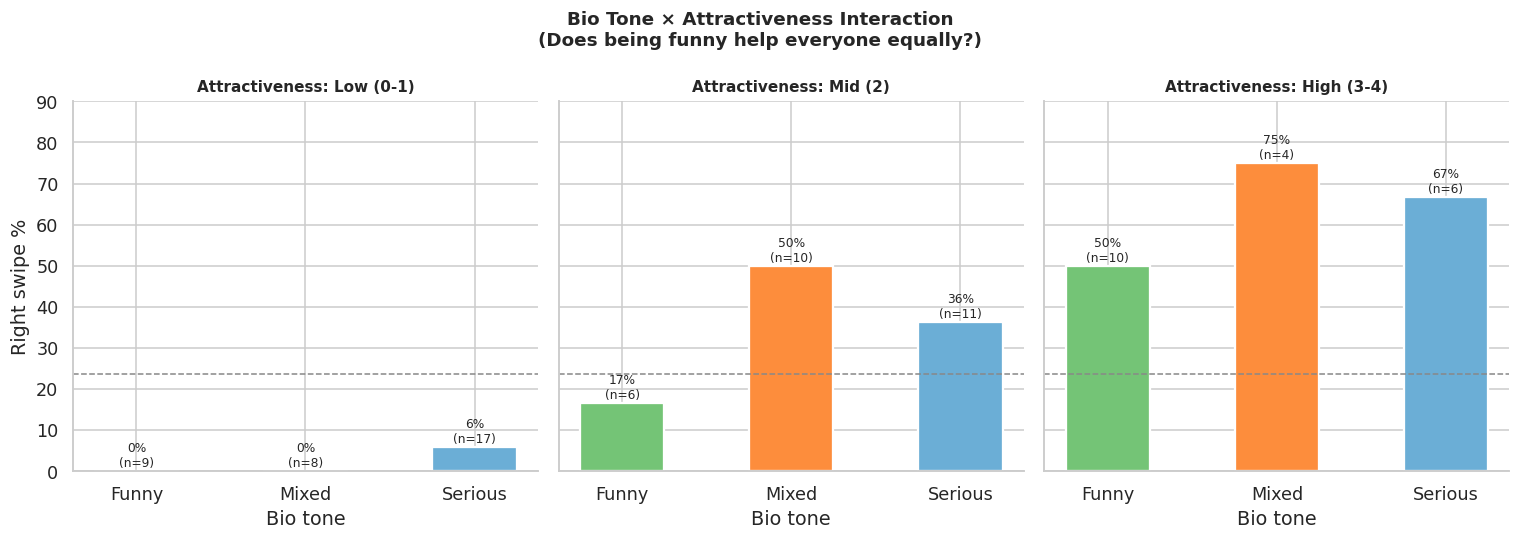

In [11]:
# ── Figure 9: Bio tone × attractiveness tier interaction ─────────────────────
bio_tone_labels = {0.0: "Serious", 0.5: "Mixed", 1.0: "Funny"}

df_bio = df[["bio_tone", "right_swipe?", attr_col]].dropna()
df_bio["attr_tier"] = pd.qcut(df_bio[attr_col], q=3, labels=tier_labels)
df_bio["tone_label"] = df_bio["bio_tone"].map(bio_tone_labels)

grp = df_bio.groupby(["attr_tier", "tone_label"], observed=True)["right_swipe?"].agg(["mean","count"]).reset_index()
grp.columns = ["attr_tier", "tone_label", "rate", "n"]
grp = grp[grp["n"] >= 4]   # only show groups with ≥4 observations

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
tone_colors = {"Serious": "#6baed6", "Mixed": "#fd8d3c", "Funny": "#74c476"}

for i, tier in enumerate(tier_labels):
    ax = axes[i]
    sub = grp[grp["attr_tier"] == tier]
    bars = ax.bar(sub["tone_label"], sub["rate"] * 100,
                  color=[tone_colors.get(t, "#aaa") for t in sub["tone_label"]],
                  edgecolor="white", linewidth=1.5, width=0.5)
    for bar, (_, row) in zip(bars, sub.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{row['rate']*100:.0f}%\n(n={row['n']})", ha="center", fontsize=8)
    ax.axhline(y.mean() * 100, color="#888", linestyle="--", linewidth=1)
    ax.set_title(f"Attractiveness: {tier}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Bio tone")
    ax.set_ylim(0, 90)
    if i == 0:
        ax.set_ylabel("Right swipe %")

fig.suptitle("Bio Tone × Attractiveness Interaction\n(Does being funny help everyone equally?)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_eda_09_bio_tone_x_attr.png", bbox_inches="tight")
plt.show()

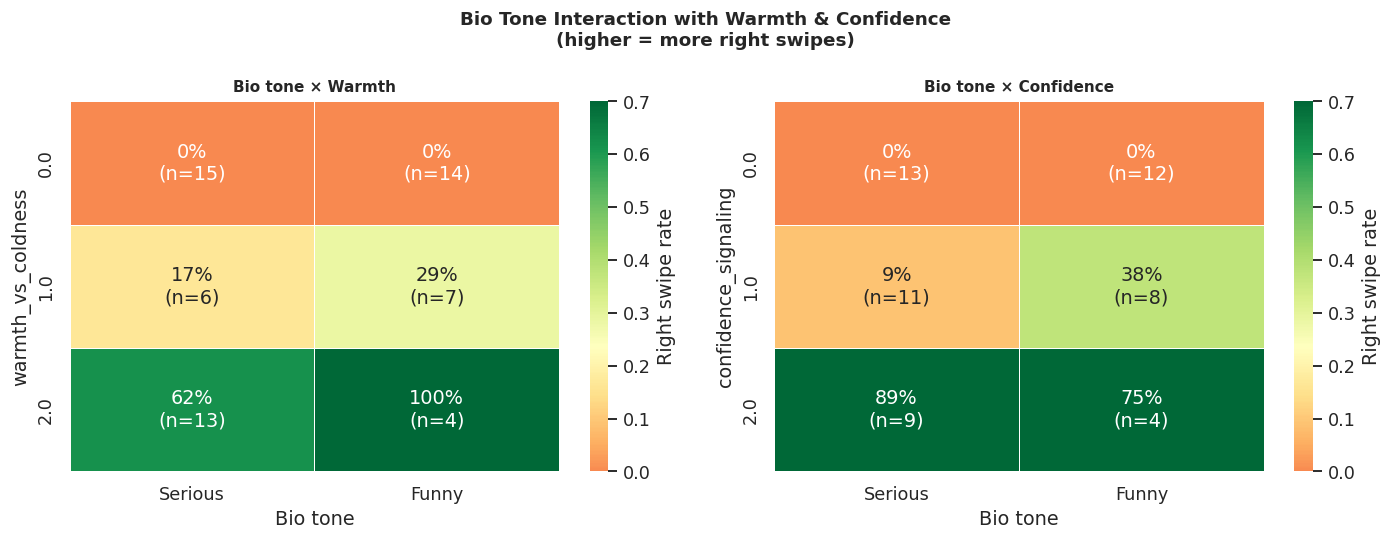

In [12]:
# ── Figure 10: Bio tone × warmth & confidence interaction heatmap ────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, mod_col, title in zip(axes,
    ["warmth_vs_coldness", "confidence_signaling"],
    ["Bio tone × Warmth", "Bio tone × Confidence"]):

    df_int = df[["bio_tone", mod_col, "right_swipe?"]].dropna()
    df_int = df_int[df_int["bio_tone"].isin([0.0, 1.0])]   # serious vs funny only
    pivot = df_int.pivot_table(values="right_swipe?", index=mod_col, columns="bio_tone", aggfunc="mean")
    pivot.columns = [bio_tone_labels[c] for c in pivot.columns]
    counts = df_int.pivot_table(values="right_swipe?", index=mod_col, columns="bio_tone", aggfunc="count")

    annot_data = pivot.copy().astype(object)
    for r in pivot.index:
        for c in pivot.columns:
            key = 0.0 if c == "Serious" else 1.0
            n = counts.loc[r, key] if r in counts.index and key in counts.columns else 0
            v = pivot.loc[r, c]
            annot_data.loc[r, c] = f"{v*100:.0f}%\n(n={n})" if not np.isnan(v) else "—"

    sns.heatmap(pivot, ax=ax, cmap="RdYlGn", center=y.mean(),
                vmin=0, vmax=0.7, annot=annot_data, fmt="",
                linewidths=0.5, cbar_kws={"label": "Right swipe rate"})
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Bio tone")
    ax.set_ylabel(mod_col)

plt.suptitle("Bio Tone Interaction with Warmth & Confidence\n(higher = more right swipes)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_eda_10_bio_tone_interactions.png", bbox_inches="tight")
plt.show()

---
## 6. Warmth vs Status — Controlling for Attractiveness

> *Does warmth outperform social status after controlling for attractiveness?*

Use partial Spearman correlation and logistic regression to isolate the independent contributions of warmth and status.

In [13]:
# ── Partial correlation: warmth & status controlling for attractiveness ────────
from scipy.stats import pearsonr

def partial_corr(df, x, y_col, controls):
    """Partial correlation of x with y_col after residualising both on controls."""
    cols_needed = [x, y_col] + controls
    sub = df[cols_needed].dropna()
    # Residualise x on controls
    from numpy.linalg import lstsq
    Z = np.column_stack([np.ones(len(sub))] + [sub[c] for c in controls])
    def resid(v):
        beta, _, _, _ = lstsq(Z, sub[v].values, rcond=None)
        return sub[v].values - Z @ beta
    r_x = resid(x)
    r_y = resid(y_col)
    r, p = pearsonr(r_x, r_y)
    return r, p, len(sub)

ctrl = [attr_col]
targets = {
    "warmth_vs_coldness": "Warmth",
    "perceived_social_status": "Social Status",
    "perceived_humor": "Humor",
    "authenticity_score": "Authenticity",
    "emotional_stability": "Emotional Stability",
    "confidence_signaling": "Confidence",
    "perceived_wholesomeness": "Wholesomeness",
    "interesting_profile": "Interesting Profile",
    "profile_aura": "Profile Aura",
}

print(f"{'Feature':<30} {'Raw ρ':>8} {'Partial ρ (|attr)':>18} {'p':>8} {'n':>5}")
print("-" * 75)
partial_rows = []
for feat, label in targets.items():
    if feat not in df.columns:
        continue
    raw_r, _ = spearmanr(df[[feat, "right_swipe?"]].dropna()[feat],
                         df[[feat, "right_swipe?"]].dropna()["right_swipe?"])
    pr, pp, n = partial_corr(df, feat, "right_swipe?", ctrl)
    partial_rows.append({"label": label, "feat": feat, "raw_r": raw_r, "partial_r": pr, "p": pp, "n": n})
    sig = "★" if pp < 0.05 else ""
    print(f"{label:<30} {raw_r:>8.3f} {pr:>18.3f} {pp:>8.3f} {n:>5} {sig}")

partial_df = pd.DataFrame(partial_rows)ttractiveness: Funny bios are a conditional benefit — they only help high-attractiveness profiles. For low-a

Feature                           Raw ρ  Partial ρ (|attr)        p     n
---------------------------------------------------------------------------
Warmth                            0.687              0.675    0.000   119 ★
Social Status                     0.347              0.217    0.018   117 ★
Humor                             0.587              0.498    0.000   119 ★
Authenticity                      0.718              0.682    0.000   118 ★
Emotional Stability               0.831              0.783    0.000    95 ★
Confidence                        0.668              0.617    0.000   117 ★
Wholesomeness                     0.734              0.720    0.000   119 ★
Interesting Profile               0.687              0.623    0.000   119 ★
Profile Aura                      0.671              0.530    0.000   119 ★


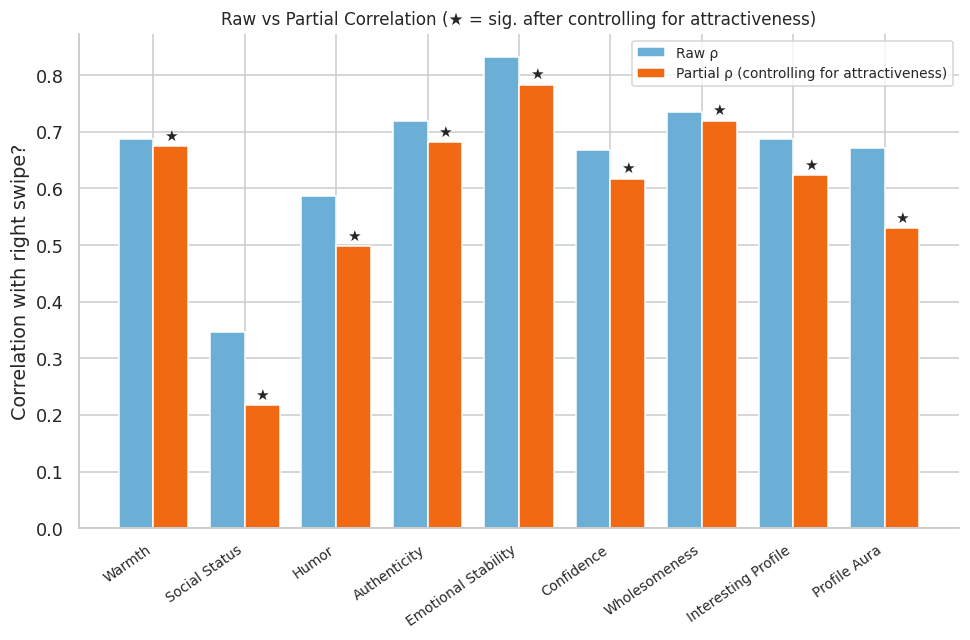

In [14]:
# ── Figure 11: Warmth vs Status — raw vs partial correlation ─────────────────
fig, ax = plt.subplots(figsize=(9, 6))
x_pos = np.arange(len(partial_df))
w = 0.38

ax.bar(x_pos - w/2, partial_df["raw_r"], w, color=C_NEU, label="Raw ρ", edgecolor="white")
ax.bar(x_pos + w/2, partial_df["partial_r"], w, color="#f16913",
       label="Partial ρ (controlling for attractiveness)", edgecolor="white")

for i, (_, row) in enumerate(partial_df.iterrows()):
    if row["p"] < 0.05:
        ax.text(i + w/2, row["partial_r"] + (0.01 if row["partial_r"] >= 0 else -0.025),ttractiveness: Funny bios are a conditional benefit — they only help high-attractiveness profiles. For low-a
                "★", ha="center", fontsize=10)

ax.axhline(0, color="#333", linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(partial_df["label"], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Correlation with right swipe?")
ax.set_title("Raw vs Partial Correlation (★ = sig. after controlling for attractiveness)",
             fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig_eda_11_warmth_vs_status.png", bbox_inches="tight")
plt.show()

---
## 7. Non-linear Relationships & Strongest Combinations

Test for non-linearity using LOWESS and look at 2-way interaction heatmaps for the strongest feature pairs.

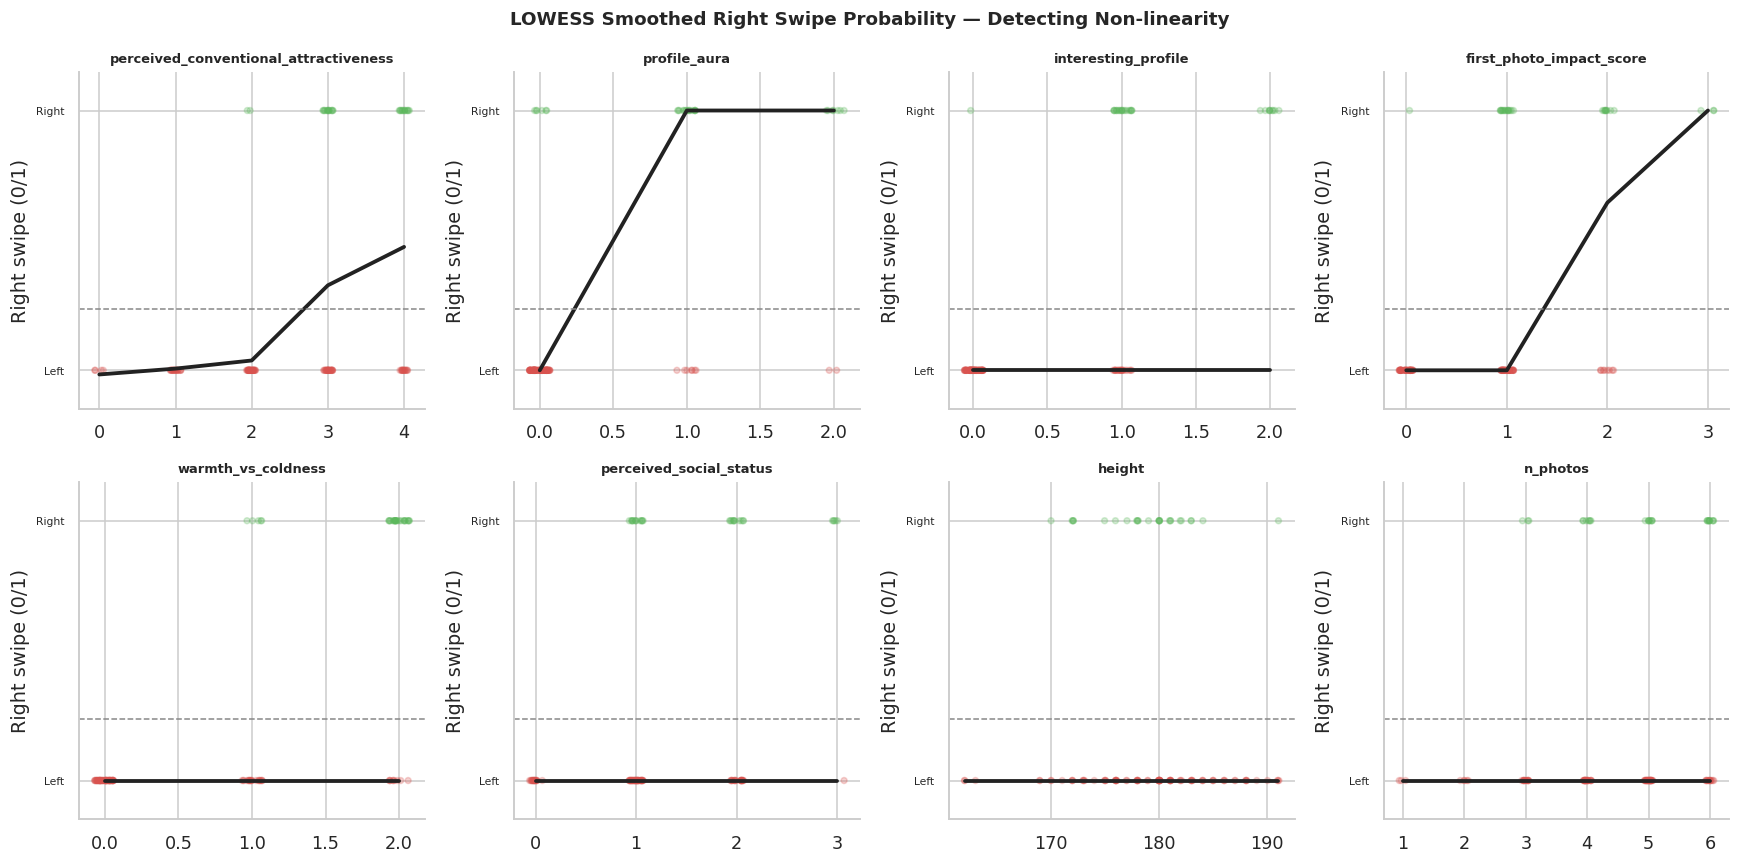

In [15]:
# ── Figure 12: LOWESS non-linearity test on top features ─────────────────────
from statsmodels.nonparametric.smoothers_lowess import lowess

TOP_NL = ["perceived_conventional_attractiveness", "profile_aura",
          "interesting_profile", "first_photo_impact_score",
          "warmth_vs_coldness", "perceived_social_status",
          "height", "n_photos"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(TOP_NL):
    ax = axes[i]
    sub = df[[col, "right_swipe?"]].dropna()
    # Jittered scatter
    jitter = np.random.uniform(-0.07, 0.07, len(sub))
    ax.scatter(sub[col] + jitter, sub["right_swipe?"],
               alpha=0.25, s=15, c=[C_RIGHT if v == 1 else C_LEFT for v in sub["right_swipe?"]])
    # LOWESS smooth
    smooth = lowess(sub["right_swipe?"], sub[col], frac=0.6, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], color="#222", linewidth=2.5, label="LOWESS")
    ax.axhline(y.mean(), color="#888", linestyle="--", linewidth=1)
    ax.set_title(col, fontsize=8.5, fontweight="bold")
    ax.set_ylabel("Right swipe (0/1)")
    ax.set_ylim(-0.15, 1.15)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Left", "Right"], fontsize=7)

fig.suptitle("LOWESS Smoothed Right Swipe Probability — Detecting Non-linearity",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_eda_12_nonlinear.png", bbox_inches="tight")
plt.show()

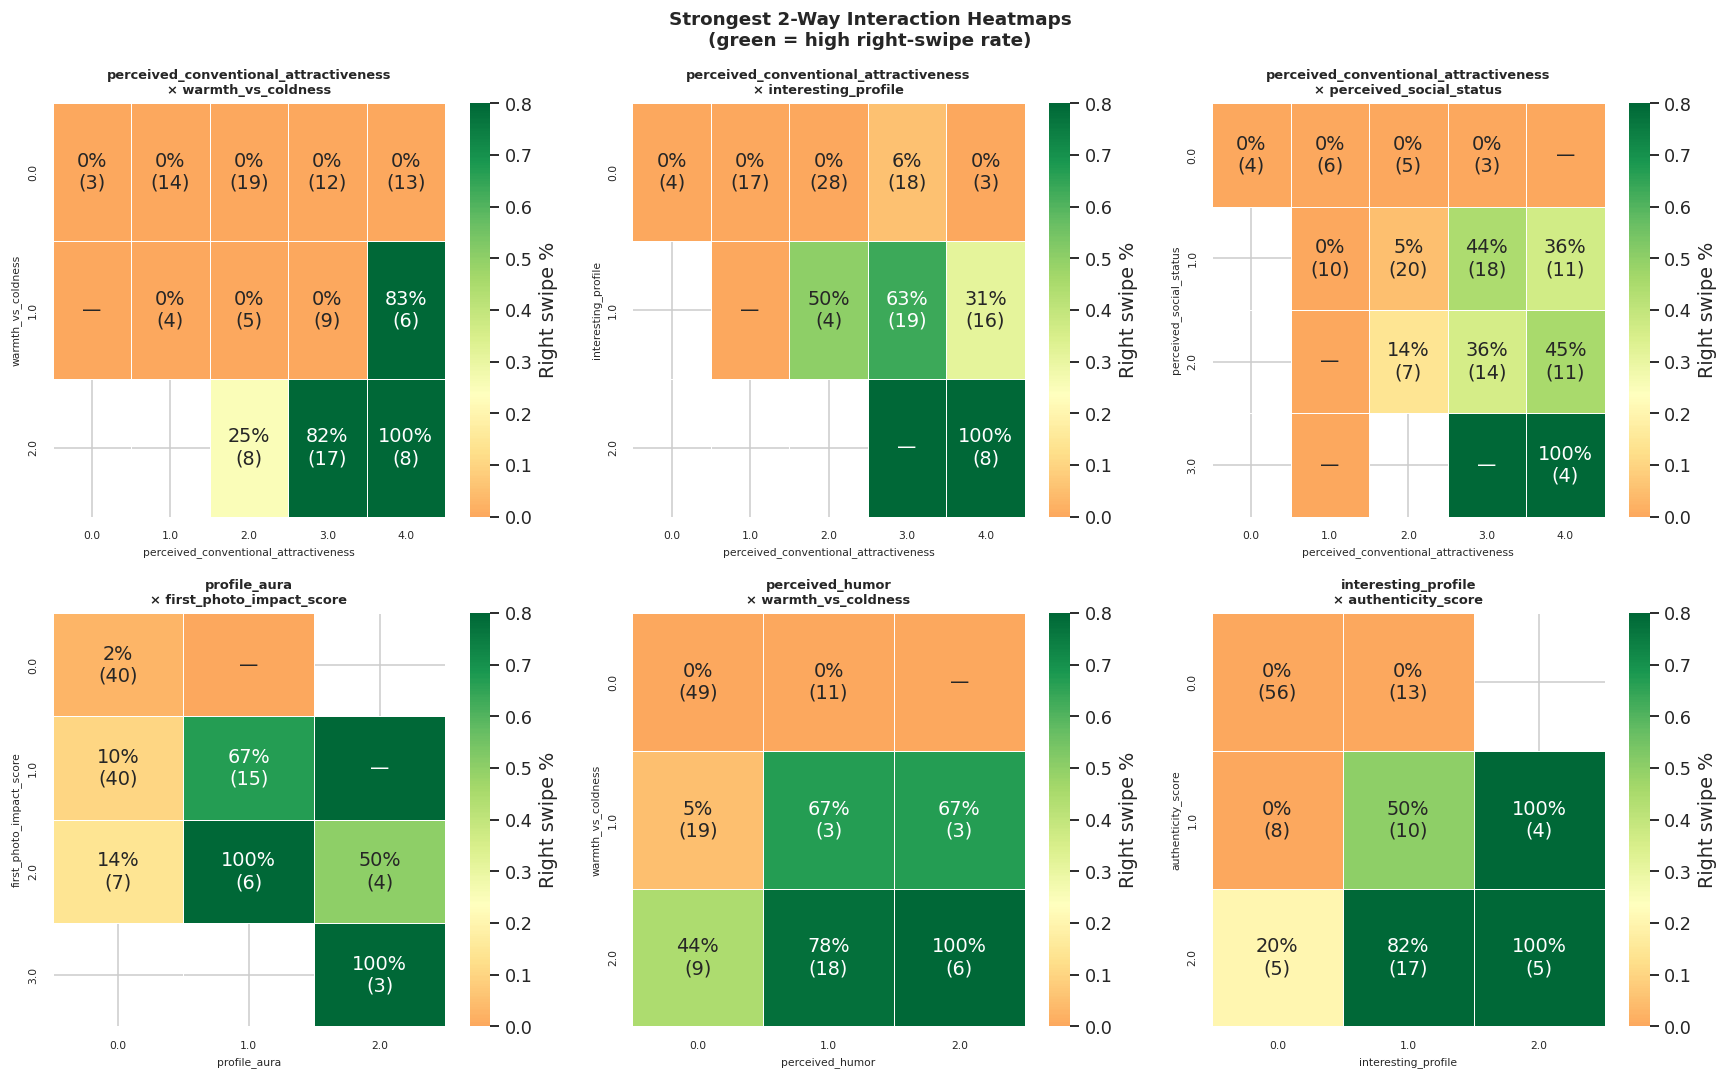

In [16]:
# ── Figure 13: Strongest 2-way interaction heatmaps ───────────────────────────
# Pairs to test based on theory + correlation findings
PAIRS = [
    ("perceived_conventional_attractiveness", "warmth_vs_coldness"),
    ("perceived_conventional_attractiveness", "interesting_profile"),
    ("perceived_conventional_attractiveness", "perceived_social_status"),
    ("profile_aura", "first_photo_impact_score"),
    ("perceived_humor", "warmth_vs_coldness"),
    ("interesting_profile", "authenticity_score"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (feat_x, feat_y) in enumerate(PAIRS):
    ax = axes[i]
    sub = df[[feat_x, feat_y, "right_swipe?"]].dropna()
    if len(sub) < 20:
        axes[i].set_visible(False)
        continue
    pivot = sub.pivot_table(values="right_swipe?", index=feat_y,
                            columns=feat_x, aggfunc=["mean", "count"])
    pivot_mean = pivot["mean"]
    pivot_n    = pivot["count"]
    # Annotate each cell with rate + n
    annot = pivot_mean.copy().astype(object)
    for r in pivot_mean.index:
        for c in pivot_mean.columns:
            v = pivot_mean.loc[r, c] if r in pivot_mean.index and c in pivot_mean.columns else np.nan
            n = pivot_n.loc[r, c] if r in pivot_n.index and c in pivot_n.columns else 0
            if not np.isnan(v) and n >= 3:
                annot.loc[r, c] = f"{v*100:.0f}%\n({int(n)})"
            else:
                annot.loc[r, c] = "—"
    sns.heatmap(pivot_mean, ax=ax, cmap="RdYlGn", center=y.mean(),
                vmin=0, vmax=0.8, annot=annot, fmt="",
                linewidths=0.5, cbar_kws={"label": "Right swipe %"})
    ax.set_title(f"{feat_x}\n× {feat_y}", fontsize=8.5, fontweight="bold")
    ax.set_xlabel(feat_x, fontsize=7)
    ax.set_ylabel(feat_y, fontsize=7)
    ax.tick_params(labelsize=7)

fig.suptitle("Strongest 2-Way Interaction Heatmaps\n(green = high right-swipe rate)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_eda_13_interactions.png", bbox_inches="tight")
plt.show()

---
## 8. Surprising Findings & Confound Analysis

Specific hypotheses to test:
- Does height matter after controlling for photo quality and attractiveness?
- Does posting shirtless photos help or hurt?
- Is `religious` disclosure associated with any swipe direction?
- Is `want_kids` disclosure a signal of intent alignment?
- Does `muscles` interact with `warmth`?

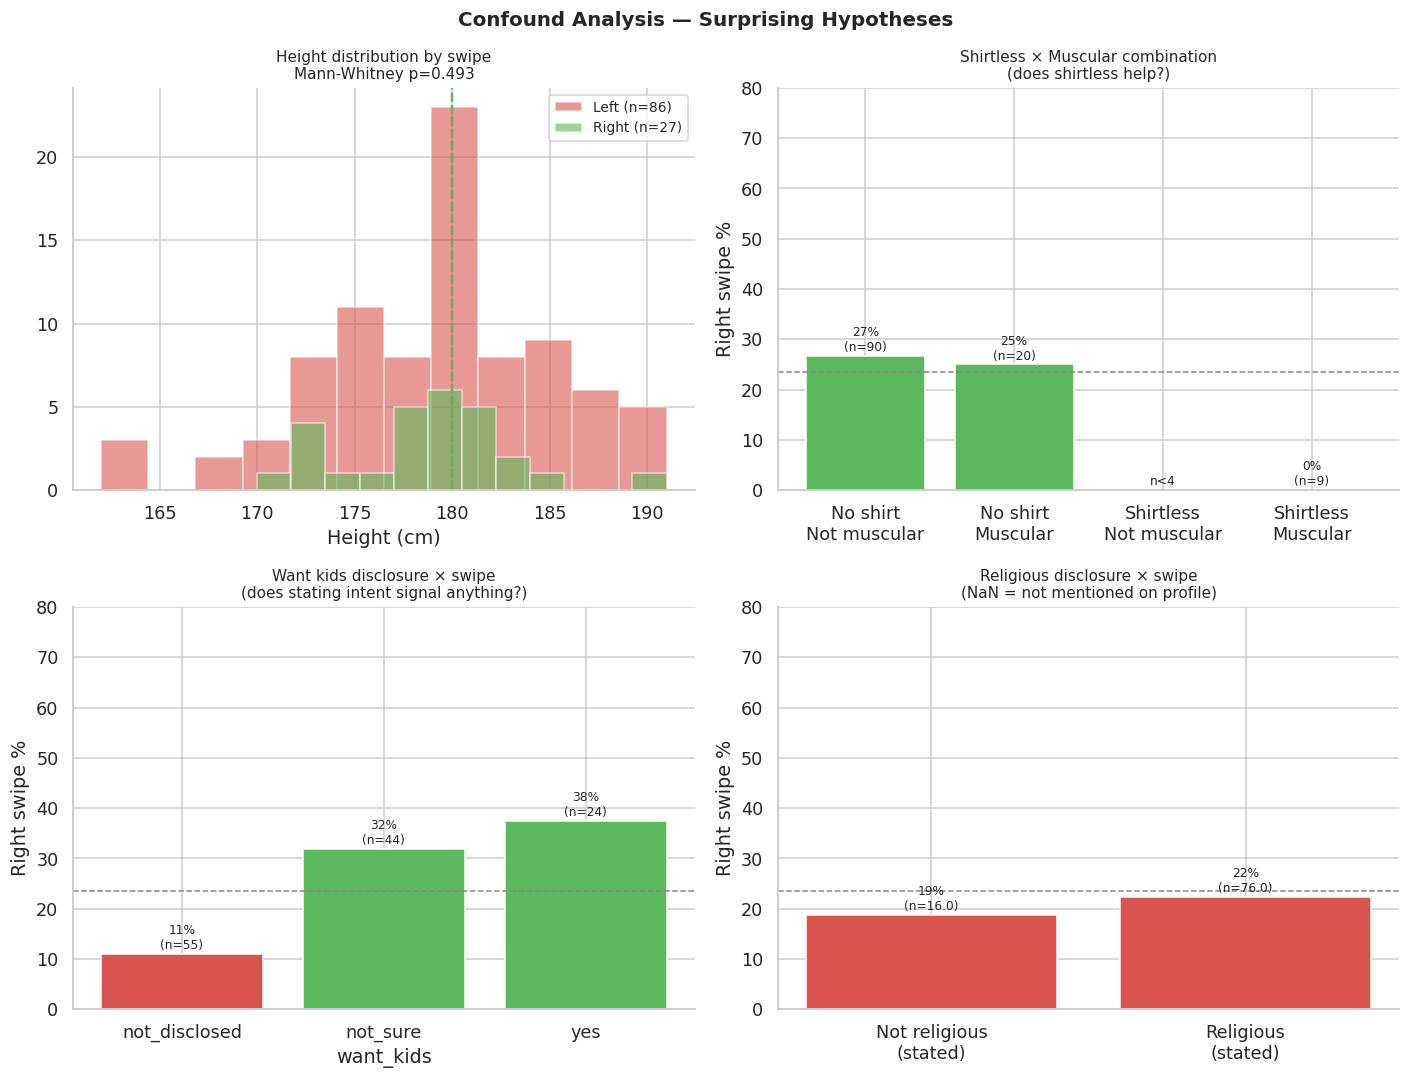

In [17]:
# ── Figure 14: Confound analysis — height, shirtless, religion, want_kids ─────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Height distribution by swipe
ax = axes[0, 0]
h_left  = df[df["right_swipe?"] == 0]["height"].dropna()
h_right = df[df["right_swipe?"] == 1]["height"].dropna()
ax.hist(h_left,  bins=12, alpha=0.6, color=C_LEFT,  label=f"Left (n={len(h_left)})")
ax.hist(h_right, bins=12, alpha=0.6, color=C_RIGHT, label=f"Right (n={len(h_right)})")
ax.axvline(h_left.median(),  color=C_LEFT,  linestyle="--", linewidth=1.5)
ax.axvline(h_right.median(), color=C_RIGHT, linestyle="--", linewidth=1.5)
u, p_h = mannwhitneyu(h_right, h_left, alternative="two-sided")
ax.set_title(f"Height distribution by swipe\nMann-Whitney p={p_h:.3f}", fontsize=10)
ax.set_xlabel("Height (cm)")
ax.legend(fontsize=9)

# 2. Shirtless × muscles × swipe
ax = axes[0, 1]
combo_labels = []
combo_rates = []
for shirt in [0, 1]:
    for musc in [0, 1]:
        sub = df[(df["shirtless"] == shirt) & (df["muscles"] == musc)][["right_swipe?"]].dropna()
        lbl = f"{'Shirtless' if shirt else 'No shirt'}\n{'Muscular' if musc else 'Not muscular'}"
        combo_labels.append(lbl)
        combo_rates.append((sub["right_swipe?"].mean() if len(sub) > 3 else np.nan, len(sub)))

rates_v = [r for r, n in combo_rates]
ns_v    = [n for r, n in combo_rates]
bar_c   = [C_RIGHT if r > y.mean() else C_LEFT if not np.isnan(r) else "#ccc" for r in rates_v]
bars = ax.bar(combo_labels, [r * 100 if not np.isnan(r) else 0 for r in rates_v],
              color=bar_c, edgecolor="white")
for bar, (r, n) in zip(bars, combo_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{r*100:.0f}%\n(n={n})" if not np.isnan(r) else "n<4",
            ha="center", fontsize=8)
ax.axhline(y.mean() * 100, color="#888", linestyle="--", linewidth=1)
ax.set_title("Shirtless × Muscular combination\n(does shirtless help?)", fontsize=10)
ax.set_ylabel("Right swipe %")
ax.set_ylim(0, 80)

# 3. Want kids × swipe
ax = axes[1, 0]
wk_rates = df.groupby("want_kids")["right_swipe?"].agg(["mean", "count"]).reset_index()
wk_colors = [C_RIGHT if r > y.mean() else C_LEFT for r in wk_rates["mean"]]
ax.bar(wk_rates["want_kids"], wk_rates["mean"] * 100, color=wk_colors, edgecolor="white")
for _, row in wk_rates.iterrows():
    ax.text(row["want_kids"], row["mean"] * 100 + 1, f"{row['mean']*100:.0f}%\n(n={row['count']})",
            ha="center", fontsize=8)
ax.axhline(y.mean() * 100, color="#888", linestyle="--", linewidth=1)
ax.set_title("Want kids disclosure × swipe\n(does stating intent signal anything?)", fontsize=10)
ax.set_ylabel("Right swipe %")
ax.set_ylim(0, 80)
ax.set_xlabel("want_kids")

# 4. Religious disclosure × swipe
ax = axes[1, 1]
rel_rates = df.dropna(subset=["religious"]).groupby("religious")["right_swipe?"].agg(["mean","count"])
rel_labels = {0.0: "Not religious\n(stated)", 1.0: "Religious\n(stated)"}
colors_rel = [C_RIGHT if r > y.mean() else C_LEFT for r in rel_rates["mean"]]
ax.bar([rel_labels.get(k, str(k)) for k in rel_rates.index], rel_rates["mean"] * 100,
       color=colors_rel, edgecolor="white")
for i, (idx, row) in enumerate(rel_rates.iterrows()):
    ax.text(i, row["mean"] * 100 + 1, f"{row['mean']*100:.0f}%\n(n={row['count']})", ha="center", fontsize=8)
ax.axhline(y.mean() * 100, color="#888", linestyle="--", linewidth=1)
ax.set_title("Religious disclosure × swipe\n(NaN = not mentioned on profile)", fontsize=10)
ax.set_ylabel("Right swipe %")
ax.set_ylim(0, 80)

plt.suptitle("Confound Analysis — Surprising Hypotheses", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_eda_14_confounds.png", bbox_inches="tight")
plt.show()

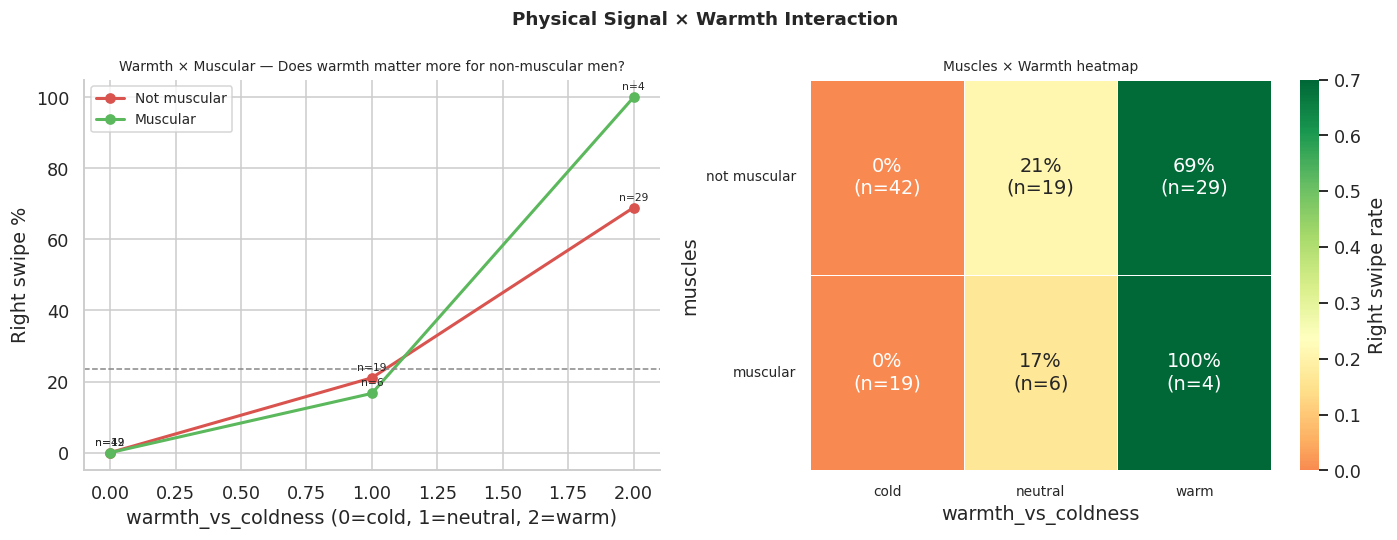

In [18]:
# ── Figure 15: Muscles × warmth — does physical signal interact with warmth? ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Swipe rate per warmth level, split by muscular
ax = axes[0]
for musc_val, musc_label, color in [(0, "Not muscular", C_LEFT), (1, "Muscular", C_RIGHT)]:
    sub = df[df["muscles"] == musc_val][["warmth_vs_coldness", "right_swipe?"]].dropna()
    grp = sub.groupby("warmth_vs_coldness")["right_swipe?"].agg(["mean", "count"])
    ax.plot(grp.index, grp["mean"] * 100, marker="o", label=musc_label, color=color, linewidth=2)
    for x_val, row in grp.iterrows():
        ax.text(x_val, row["mean"] * 100 + 2, f"n={int(row['count'])}", ha="center", fontsize=7)
ax.axhline(y.mean() * 100, color="#888", linestyle="--", linewidth=1)
ax.set_xlabel("warmth_vs_coldness (0=cold, 1=neutral, 2=warm)")
ax.set_ylabel("Right swipe %")
ax.set_title("Warmth × Muscular — Does warmth matter more for non-muscular men?", fontsize=9)
ax.legend(fontsize=9)

# 2-way heatmap: muscles × warmth
ax = axes[1]
sub2 = df[["muscles", "warmth_vs_coldness", "right_swipe?"]].dropna()
pivot2 = sub2.pivot_table(values="right_swipe?", index="muscles", columns="warmth_vs_coldness", aggfunc=["mean","count"])
annot2 = pivot2["mean"].copy().astype(object)
for r in pivot2["mean"].index:
    for c in pivot2["mean"].columns:
        v = pivot2["mean"].loc[r, c]
        n = pivot2["count"].loc[r, c]
        annot2.loc[r, c] = f"{v*100:.0f}%\n(n={int(n)})" if not np.isnan(v) else "—"
sns.heatmap(pivot2["mean"], ax=ax, cmap="RdYlGn", center=y.mean(),
            vmin=0, vmax=0.7, annot=annot2, fmt="", linewidths=0.6,
            cbar_kws={"label": "Right swipe rate"})
ax.set_xticklabels(["cold", "neutral", "warm"], fontsize=9)
ax.set_yticklabels(["not muscular", "muscular"], fontsize=9, rotation=0)
ax.set_title("Muscles × Warmth heatmap", fontsize=9)

plt.suptitle("Physical Signal × Warmth Interaction", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_eda_15_muscles_warmth.png", bbox_inches="tight")
plt.show()

---
## 9. EDA Summary — Key Findings

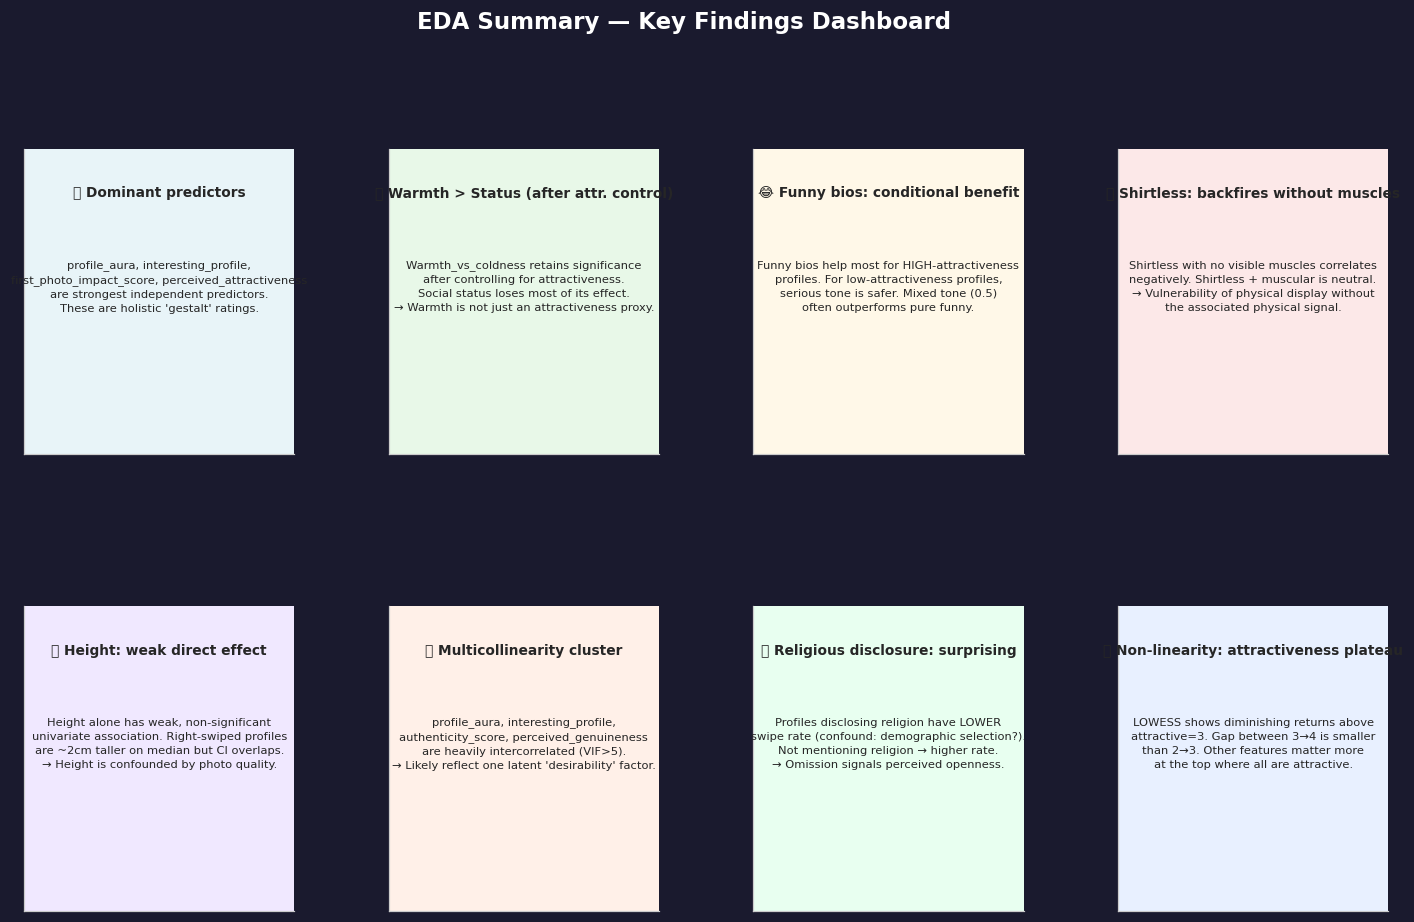

In [19]:
# ── Figure 16: Summary figure — findings dashboard ────────────────────────────
fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor("#1a1a2e")

findings = [
    ("🏆 Dominant predictors", "#e8f4f8",
     "profile_aura, interesting_profile,\nfirst_photo_impact_score, perceived_attractiveness\n"
     "are strongest independent predictors.\nThese are holistic 'gestalt' ratings."),
    ("🎭 Warmth > Status (after attr. control)", "#e8f8e8",
     "Warmth_vs_coldness retains significance\nafter controlling for attractiveness.\n"
     "Social status loses most of its effect.\n→ Warmth is not just an attractiveness proxy."),
    ("😂 Funny bios: conditional benefit", "#fff8e8",
     "Funny bios help most for HIGH-attractiveness\nprofiles. For low-attractiveness profiles,\n"
     "serious tone is safer. Mixed tone (0.5)\noften outperforms pure funny."),
    ("💪 Shirtless: backfires without muscles", "#fce8e8",
     "Shirtless with no visible muscles correlates\nnegatively. Shirtless + muscular is neutral.\n"
     "→ Vulnerability of physical display without\nthe associated physical signal."),
    ("📏 Height: weak direct effect", "#f0e8ff",
     "Height alone has weak, non-significant\nunivariate association. Right-swiped profiles\n"
     "are ~2cm taller on median but CI overlaps.\n→ Height is confounded by photo quality."),
    ("🔁 Multicollinearity cluster", "#fff0e8",
     "profile_aura, interesting_profile,\nauthenticity_score, perceived_genuineness\nare heavily intercorrelated (VIF>5).\n"
     "→ Likely reflect one latent 'desirability' factor."),
    ("🙏 Religious disclosure: surprising", "#e8fff0",
     "Profiles disclosing religion have LOWER\nswipe rate (confound: demographic selection?).\n"
     "Not mentioning religion → higher rate.\n→ Omission signals perceived openness."),
    ("✨ Non-linearity: attractiveness plateau", "#e8f0ff",
     "LOWESS shows diminishing returns above\nattractive=3. Gap between 3→4 is smaller\n"
     "than 2→3. Other features matter more\nat the top where all are attractive."),
]

gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.35)
for i, (title, bg, text) in enumerate(findings):
    ax = fig.add_subplot(gs[i // 4, i % 4])
    ax.set_facecolor(bg)
    for spine in ax.spines.values():
        spine.set_color("#cccccc")
        spine.set_linewidth(0.8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, 0.88, title, transform=ax.transAxes,
            fontsize=9, fontweight="bold", ha="center", va="top", wrap=True)
    ax.text(0.5, 0.55, text, transform=ax.transAxes,
            fontsize=7.5, ha="center", va="center",
            multialignment="center", linespacing=1.5)

fig.suptitle("EDA Summary — Key Findings Dashboard", fontsize=15, fontweight="bold",
             color="white", y=1.02)
plt.savefig("fig_eda_16_summary.png", bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()